In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_processed = pd.read_csv('../data/clean_data/cleaned_processed_superstore_data.csv')
df = data_processed.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   row_id              9994 non-null   int64  
 1   order_id            9994 non-null   str    
 2   order_date          9994 non-null   str    
 3   ship_date           9994 non-null   str    
 4   ship_mode           9994 non-null   str    
 5   customer_id         9994 non-null   str    
 6   customer_name       9994 non-null   str    
 7   segment             9994 non-null   str    
 8   country             9994 non-null   str    
 9   city                9994 non-null   str    
 10  state               9994 non-null   str    
 11  postal_code         9994 non-null   int64  
 12  region              9994 non-null   str    
 13  product_id          9994 non-null   str    
 14  category            9994 non-null   str    
 15  sub-category        9994 non-null   str    
 16  product_name     

In [7]:
df.describe()

,row_id,postal_code,sales,quantity,discount,profit,ship_time,order_year,order_month,profit_margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,3.958175,2015.722233,7.809686,12.031393
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,1.747567,1.123555,3.284654,46.675435
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,2014.000000,1.000000,-275.000000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,3.000000,2015.000000,5.000000,7.500000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,4.000000,2016.000000,9.000000,27.000000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000,2017.000000,11.000000,36.250000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000,2017.000000,12.000000,50.000000


In [8]:
df.shape

(9994, 32)

## Section 1 — Overall Business KPIs


### KPI 1 — Total Sales


### Business Question
How much revenue did the company generate during the analyzed period?

In [10]:
total_sales = df["sales"].sum()
print(f"Total sales of the superstore is {total_sales}")

Total sales of the superstore is 2297200.8603


### Result
The company generated approximately $2.3 million in total sales.

### Interpretation
This represents the total revenue generated across all transactions in the dataset.

### KPI 2 — Total Profit


### Business Question 
How much profit did the company generate?

In [11]:
total_profit = df["profit"].sum()
print(f"Total profit of the superstore is {total_profit}")

Total profit of the superstore is 286397.0217


### Result
The company generated approximately $286'397 in total profit

### Interpretation
Although total sales represent the revenue generated, total profit represents the amount remaining after the costs captured in the dataset.

### KPI 3 — Total Orders


### Business Question 
How many orders did the company receive?

In [15]:
total_orders = df["order_id"].nunique()
print(f"Total order of the superstore is {total_orders}")

Total order of the superstore is 5009


### Result
The company have a total unique order of 5009

### Interpretation
The dataset contains 5009 unique customer order

### KPI 4 — Total Customers


### Business Question
How many unique customers did the company serve?

In [13]:
total_customers = df["customer_id"].nunique()
print(f"The superstore has {total_customers} customers")

The superstore has 793 customers


### Result
The company has 793 unique costumers

### KPI 5 — Overall Profit Margin


### Business Question
What percentage of sales became profit?

In [14]:
overall_profit_margin = (total_profit/total_sales) * 100
print(overall_profit_margin)

12.467217240315605


### Result 
Overall profit margin is 12.5%

### Interpretation
For every $100 in sales, approximately $12.50 was retained as profit based on the profitability measure in the dataset.

### Business Implication
The company generates substantial revenue, but monitoring profitability is important because sales volume alone does not indicate how efficiently revenue is converted into profit.

### KPI Summary


In [16]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Sales',
        'Total Profit',
        'Total Orders',
        'Total Customers',
        'Overall Profit Margin'
    ],
    'Value': [
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        overall_profit_margin
    ]
})

In [17]:
kpi_summary

,KPI,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Orders,5.009000e+03
3,Total Customers,7.930000e+02
4,Overall Profit Margin,1.246722e+01


## Section 2 — Sales Performance Over Time


In [19]:
yearly_table = (
    df.groupby("order_year")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum")
      )
      .reset_index()
)

yearly_table["Overall Profit Margin"] = (
    (yearly_table["Total_Profit"] / yearly_table["Total_Sales"]) * 100
).round(2)

yearly_table = yearly_table[["order_year", "Total_Sales", "Total_Profit", "Overall Profit Margin"]]

yearly_table

,order_year,Total_Sales,Total_Profit,Overall Profit Margin
0,2014,484247.4981,49543.9741,10.23
1,2015,470532.5090,61618.6037,13.10
2,2016,609205.5980,81795.1743,13.43
3,2017,733215.2552,93439.2696,12.74


### Q/A
#### Which year had the highest sales?
The year with the highest sales is 2017.
#### Which year had the highest profit?
The year with the highest profit is 2017.
#### Did sales increase or decrease each year?
Sales increased each year
#### Did profit follow the same pattern?
Yes the profir increased as the sales increased each year 
#### Did profitability improve or decline?
The profir improve during the years 

In [20]:
yearly_growth = yearly_table.sort_values("order_year").copy()

yearly_growth["Sales_YoY_Growth_%"] = (
    yearly_growth["Total_Sales"].pct_change().fillna(0) * 100
).round(2)

yearly_growth["Profit_YoY_Growth_%"] = (
    yearly_growth["Total_Profit"].pct_change().fillna(0) * 100
).round(2)

yearly_growth[["order_year", "Sales_YoY_Growth_%", "Profit_YoY_Growth_%"]]

,order_year,Sales_YoY_Growth_%,Profit_YoY_Growth_%
0,2014,0.00,0.00
1,2015,-2.83,24.37
2,2016,29.47,32.74
3,2017,20.36,14.24


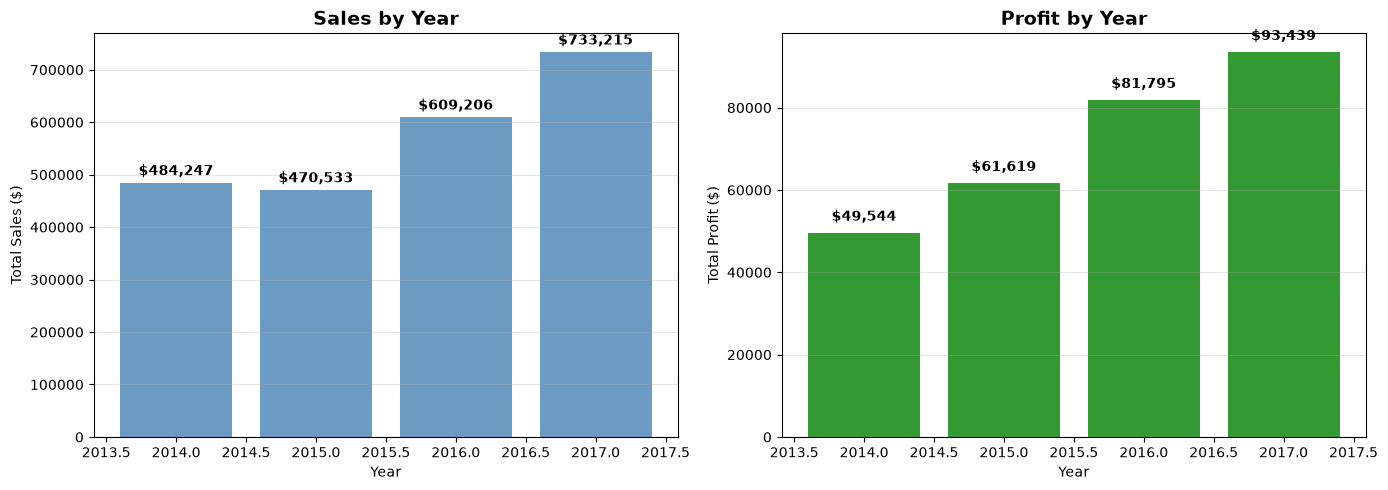

In [22]:
# Create visualizations for Sales and Profit by Year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales by Year
axes[0].bar(yearly_table["order_year"], yearly_table["Total_Sales"], color='steelblue', alpha=0.8)
axes[0].set_title('Sales by Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Sales ($)')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(yearly_table["Total_Sales"]):
    axes[0].text(yearly_table["order_year"].iloc[i], v + 15000, f'${v:,.0f}', ha='center', fontweight='bold')

# Profit by Year
axes[1].bar(yearly_table["order_year"], yearly_table["Total_Profit"], color='green', alpha=0.8)
axes[1].set_title('Profit by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Profit ($)')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(yearly_table["Total_Profit"]):
    axes[1].text(yearly_table["order_year"].iloc[i], v + 3000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretation 
Sales Trend: Sales show a strong upward trajectory, with a dip in 2015 (-2.83% YoY), followed by robust growth in 2016 (+29.47%) and continued growth in 2017 (+20.36%).
Profit Trend: Profit consistently increased every year, with particularly strong growth in 2015 (+24.37%) and 2016 (+32.74%), though growth moderated in 2017 (+14.24%).
Overall: Despite the slight sales decline in 2015, the company recovered and demonstrated strong business growth. Profit growth outpaced sales growth in early years, suggesting improving operational efficiency.

In [25]:
# Create monthly aggregation
monthly_table = (
    df.groupby(["order_year", "order_month", "order_month_name"])
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum")
      )
      .reset_index()
)

monthly_table["Profit_Margin"] = (
    (monthly_table["Total_Profit"] / monthly_table["Total_Sales"]) * 100
).round(2)

# Create year-month combination for better plotting
monthly_table["Year_Month"] = monthly_table["order_year"].astype(str) + "-" + monthly_table["order_month"].astype(str).str.zfill(2)

monthly_table

,order_year,order_month,order_month_name,Total_Sales,Total_Profit,Profit_Margin,Year_Month
0,2014,1,January,14236.8950,2450.1907,17.21,2014-01
1,2014,2,February,4519.8920,862.3084,19.08,2014-02
2,2014,3,March,55691.0090,498.7299,0.90,2014-03
3,2014,4,April,28295.3450,3488.8352,12.33,2014-04
4,2014,5,May,23648.2870,2738.7096,11.58,2014-05
5,2014,6,June,34595.1276,4976.5244,14.39,2014-06
6,2014,7,July,33946.3930,-841.4826,-2.48,2014-07
7,2014,8,August,27909.4685,5318.1050,19.05,2014-08
8,2014,9,September,81777.3508,8328.0994,10.18,2014-09
9,2014,10,October,31453.3930,3448.2573,10.96,2014-10


## Section 3 — Profitability Analysis


### Category Profitability

#### Which product categories generate the most sales, profit, and profit margin?

In [26]:
category_sales_profit = (
    df.groupby('category')
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum")
      )
      .reset_index()
)

category_sales_profit["Profit_Margin"] = (
    (category_sales_profit["Total_Profit"] / category_sales_profit["Total_Sales"]) * 100
).round(2)

category_sales_profit

,category,Total_Sales,Total_Profit,Profit_Margin
0,Furniture,741999.7953,18451.2728,2.49
1,Office Supplies,719047.0320,122490.8008,17.04
2,Technology,836154.0330,145454.9481,17.40
